In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline

In [3]:
os.getcwd()

'C:\\Users\\gokhan\\anaconda_projects\\MLNotebooks'

In [4]:
df=pd.read_csv("1-studyhours.csv")

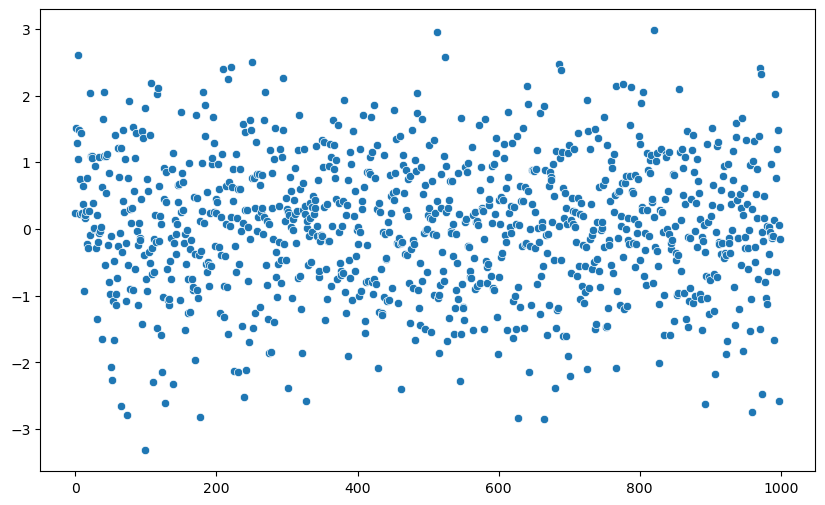

In [5]:
#Testing %matplotlib inline
demo = np.random.standard_normal(1000)
plt.figure(figsize=(10,6))
sns.scatterplot(demo)
plt.show()

In [6]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [7]:
df.tail()

,Study Hours,Exam Score
28,17.7,79.1
29,19.5,82.4
30,23.4,91.5
31,25.2,96.2
32,18.9,89.6


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [9]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


In [10]:
df[df["Study Hours"]==30.0]

,Study Hours,Exam Score
12,30.0,92.0


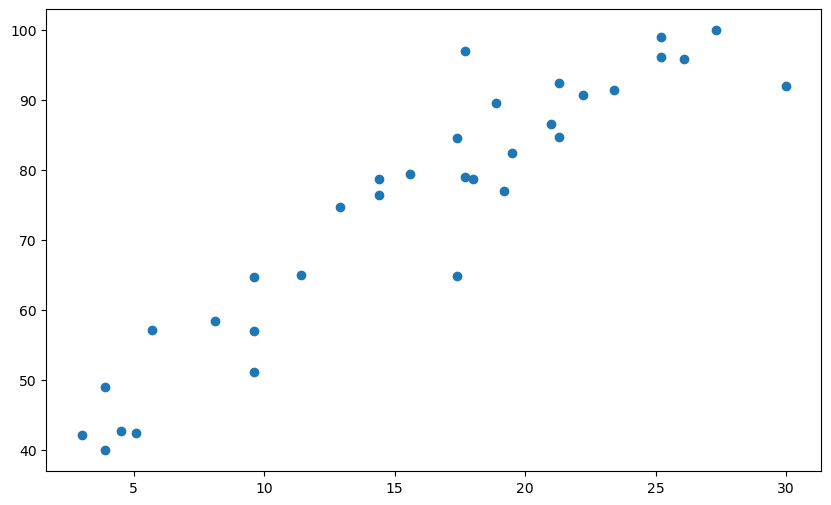

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(x=df["Study Hours"],y=df["Exam Score"])
plt.show()

In [12]:
#independent and dependent features
X = df[["Study Hours"]]
y = df["Exam Score"]


In [13]:
type(X)

pandas.core.frame.DataFrame

In [14]:
type(y)

pandas.core.series.Series

In [15]:
# Test - Train Split

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 44)

In [18]:
X_train

,Study Hours
16,5.7
14,21.0
25,5.1
8,25.2
1,9.6
9,17.4
23,3.0
4,14.4
5,18.0
29,19.5


In [19]:
X_test

,Study Hours
30,23.4
11,26.1
22,14.4
2,4.5
26,9.6
18,17.4
12,30.0


In [20]:
y_train

16     57.2
14     86.6
25     42.4
8      99.0
1      57.1
9      84.6
23     42.2
4      78.7
5      78.8
29     82.4
6      77.1
19     84.7
21     58.5
7      90.8
24     51.2
10     92.4
15     97.0
28     79.1
32     89.6
0      40.0
31     96.2
27     79.5
13    100.0
17     74.7
3      65.1
20     49.0
Name: Exam Score, dtype: float64

In [21]:
y_test

30    91.5
11    95.9
22    76.5
2     42.7
26    64.8
18    64.9
12    92.0
Name: Exam Score, dtype: float64

In [22]:
# Standardize the data set

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # fit --> data leakage

In [26]:
X_train

array([[-1.3393734 ],
       [ 0.81859638],
       [-1.42399967],
       [ 1.41098024],
       [-0.78930267],
       [ 0.31083878],
       [-1.7201916 ],
       [-0.11229255],
       [ 0.39546505],
       [ 0.60703072],
       [ 0.56471758],
       [ 0.86090951],
       [-1.00086834],
       [ 0.98784891],
       [-0.78930267],
       [ 0.86090951],
       [ 0.35315192],
       [ 0.35315192],
       [ 0.52240445],
       [-1.5932522 ],
       [ 1.41098024],
       [ 0.05695999],
       [ 1.70717217],
       [-0.32385821],
       [-0.53542388],
       [-1.5932522 ]])

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
regression = LinearRegression()

In [29]:
regression.fit(X_train,y_train)

LinearRegression()

In [30]:
print(f"Coefficient: {regression.coef_}, intercept: {regression.intercept_}")

Coefficient: [17.70922918], intercept: 74.38076923076922


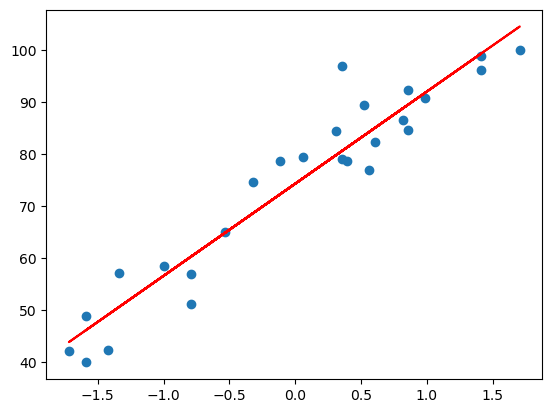

In [31]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train),"r")
plt.show()

In [32]:
regression.predict(scaler.transform([[10]]))

C:\Users\gokhan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([61.40193792])

In [33]:
regression.predict(scaler.transform([[20]]))

C:\Users\gokhan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([86.37970358])

In [34]:
regression.predict(scaler.transform([[0]]))

C:\Users\gokhan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([36.42417227])

In [35]:
regression.predict(scaler.transform([[25]]))

C:\Users\gokhan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([98.8685864])

In [36]:
# Prediction with test data

In [38]:
regression.predict(X_test)

array([ 94.8721439 , 101.61614063,  72.39215481,  47.66416681,
        60.4028273 ,  79.88548451, 111.35746923])